In [26]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의


Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [27]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import matplotlib
print(matplotlib.get_cachedir())

C:\Users\user\AppData\Local\matplotlib


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [30]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우 기본 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥OS 기본 폰트
else:
    # 리눅스 (Colab 등) 환경인 경우
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

CSV 불러오기

In [31]:
import os

base_path = r'C:\Users\user\Downloads\Olist_project'

# 지정된 폴더가 실제로 존재하고 그 안의 파일 목록을 출력
if os.path.exists(base_path):
    print(f"폴더 존재함! 파일 목록:")
    print(os.listdir(base_path))
else:
    print(f"경로가 존재하지 않습니다: {base_path}")

폴더 존재함! 파일 목록:
['.git', 'data', 'Olist_Analysis.ipynb', 'README.md']


In [32]:
import pandas as pd

# 깃허브 Raw 기반 베이스 URL
base_url = "https://raw.githubusercontent.com/roh-git/Olist_DATA_ANALYSIS_PROJECT/refs/heads/main/data/"

# 9개 파일 개별 로드
customer_df = pd.read_csv(base_url + "customers.csv")
geolocation_df = pd.read_csv(base_url + "geolocation.csv")
order_items_df = pd.read_csv(base_url + "order_items.csv")
order_payments_df = pd.read_csv(base_url + "order_payments.csv")
order_reviews_df = pd.read_csv(base_url + "order_reviews.csv")
orders_df = pd.read_csv(base_url + "orders.csv")
category_name_df = pd.read_csv(base_url + "product_category_name_translation.csv")
products_df = pd.read_csv(base_url + "products.csv")
sellers_df = pd.read_csv(base_url + "sellers.csv")

테이블 합치기

In [33]:
olist_df = pd.merge(orders_df, order_payments_df, on = 'order_id')
olist_df = olist_df.merge(customer_df, on = 'customer_id')
olist_df = olist_df.merge(order_items_df, on = 'order_id')
olist_df = olist_df.merge(products_df, on = 'product_id')
olist_df = olist_df.merge(category_name_df, on = 'product_category_name')
olist_df = olist_df.merge(order_reviews_df, on = 'order_id')
olist_df = olist_df.merge(sellers_df, on = 'seller_id')

# 컬럼 이름 변경
olist_df = olist_df.rename(columns={'geolocation_state': 'seller_state'})

# 변경 확인
print(olist_df.info())

olist_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114812 entries, 0 to 114811
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114812 non-null  str    
 1   customer_id                    114812 non-null  str    
 2   order_status                   114812 non-null  str    
 3   order_purchase_timestamp       114812 non-null  str    
 4   order_approved_at              114798 non-null  str    
 5   order_delivered_carrier_date   114087 non-null  str    
 6   order_delivered_customer_date  112943 non-null  str    
 7   order_estimated_delivery_date  114812 non-null  str    
 8   payment_sequential             114812 non-null  int64  
 9   payment_type                   114812 non-null  str    
 10  payment_installments           114812 non-null  int64  
 11  payment_value                  114812 non-null  float64
 12  customer_unique_id             114812 non

> [전처리 1] 날짜 데이터(String)를 실제 시간 데이터(Datetime)로 변환

In [34]:
import pandas as pd
from datetime import timedelta

# 분석에 사용할 주요 날짜 컬럼 목록
DATE_COLS = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# 1. 텍스트를 날짜(datetime) 타입으로 일괄 변환 (에러 발생 시 강제로 결측치 처리)
for c in DATE_COLS:
    olist_df[c] = pd.to_datetime(olist_df[c], errors='coerce')

# 2. 날짜 연산 및 중복 결제 병합을 위해 시간(시간:분:초)을 떼어낸 순수 날짜(Date) 컬럼 생성
olist_df['purchase_date'] = olist_df['order_purchase_timestamp'].dt.date

print("✅ [전처리 1 완료] 날짜 데이터 변환 완료")

✅ [전처리 1 완료] 날짜 데이터 변환 완료


> [전처리 2] 타겟 생성: 분리결제 노이즈 제거 및 30일 이내 진성 재구매(target_30d) 식별

In [35]:
# 1. 고객별 첫 구매일(min)과, 고유 구매일자 리스트(order_dates) 생성
customer_orders = olist_df.groupby('customer_unique_id').agg(
    first_order_date=('purchase_date', 'min'),
    # 같은 날짜 중복 제거를 위해 set() 사용 후 정렬
    order_dates=('purchase_date', lambda x: sorted(list(set(x))))
).reset_index()

# 2. 30일 이내 재구매 여부 판별 함수 정의
def check_30d_repurchase(dates):
    if len(dates) < 2:  # 구매일이 하루밖에 없는 사람 (단발성)
        return 0
    # 첫 구매일과 두 번째 구매일의 차이가 0초과 30일 이내면 1(재구매)
    return 1 if 0 < (dates[1] - dates[0]).days <= 30 else 0

# 3. 함수 적용하여 타겟 변수 생성
customer_orders['target_30d'] = customer_orders['order_dates'].apply(check_30d_repurchase)

print("✅ [전처리 2 완료] 진성 재구매 타겟 변수 생성 완료")

✅ [전처리 2 완료] 진성 재구매 타겟 변수 생성 완료


> [전처리 3] 관측창 통제: 분석 기간 종료 직전 가입자 제외 및 최종 데이터셋 완성

In [36]:
# 1. 전체 데이터셋의 가장 마지막 주문일 확인
max_dataset_date = olist_df['purchase_date'].max()

# 2. 마지막 주문일 기준, 최소 30일 이전에 첫 구매를 한 '시간적 여유가 있는' 고객만 필터링
# (이전에 에러가 났던 부분을 방지하기 위해 파이썬 내장 timedelta 사용)
valid_customers = customer_orders[customer_orders['first_order_date'] <= (max_dataset_date - timedelta(days=30))]

# 3. 만약 기존 olist_df에 target_30d가 잘못 붙어있다면 꼬임 방지를 위해 삭제
if 'target_30d' in olist_df.columns:
    olist_df = olist_df.drop(columns=['target_30d'])

# 4. 필터링된 유효 고객(valid_customers)과 그들의 타겟 변수를 원본 olist_df에 이너 조인(Inner Join)
olist_df = olist_df.merge(valid_customers[['customer_unique_id', 'target_30d']], on='customer_unique_id', how='inner')

print("✅ [전처리 3 완료] 관측창 통제 및 타겟 결합 완료")
print("   - 관측창 확보된 유효 데이터 크기:", olist_df.shape)

✅ [전처리 3 완료] 관측창 통제 및 타겟 결합 완료
   - 관측창 확보된 유효 데이터 크기: (108941, 41)


> [전처리 4] 가설 검증용 파생변수 생성 (배송 지연, 배송비 비율 등)

In [37]:
# 1. [통제변수] 배송 지연 여부 (실제 배송일 > 배송 예정일 이면 1, 아니면 0)
olist_df['is_late'] = (olist_df['order_delivered_customer_date'] > olist_df['order_estimated_delivery_date']).astype(int)

# 2. [가설 4] 배송비 부담률 = 배송비 / (상품가격 + 배송비)
# 분모가 0이 되어 무한대(Inf)가 나오는 것을 방지하기 위해 아주 작은 수(1e-5)를 더해줌
olist_df['freight_ratio'] = olist_df['freight_value'] / (olist_df['price'] + olist_df['freight_value'] + 1e-5)

print("✅ [전처리 4 완료] 가설 검증용 파생 변수 생성 완료")

✅ [전처리 4 완료] 가설 검증용 파생 변수 생성 완료


> [전처리 5] 중복제거 (데이터 누수 차단 및 EDA 데이터셋 분리)

In [38]:
# 1. 고객별 가장 처음 발생한 '첫 주문번호(order_id)' 찾기
first_orders = olist_df.sort_values('order_purchase_timestamp').groupby('customer_unique_id')['order_id'].first().reset_index()

# 2. 첫 주문번호에 해당하는 데이터(미래의 두 번째 결제 내역 차단)만 추출
first_purchase_df = olist_df[olist_df['order_id'].isin(first_orders['order_id'])]

# 3. 중복 제거의 올바른 방법: 고객 1명당 1줄의 요약본(eda_df)으로 집계(Aggregation)
# 이 과정에서 '가설 1. 카테고리 다양성' 검증을 위한 nunique()가 계산됩니다.
eda_df = first_purchase_df.groupby('customer_unique_id').agg(
    category_count=('product_category_name', 'nunique'),     # [가설 1] 장바구니 속 카테고리 종류 수
    purchase_date=('order_purchase_timestamp', 'first'),     # [가설 2] 구매 일자
    installments=('payment_installments', 'max'),            # [가설 3] 최대 할부 개월 수
    freight_ratio=('freight_ratio', 'mean'),                 # [가설 4] 장바구니 평균 배송비 부담률
    review_score=('review_score', 'first'),                  # [가설 5] 첫 리뷰 점수
    is_late=('is_late', 'max'),                              # 배송 지연 경험 여부 (하나라도 지연됐으면 1)
    target_30d=('target_30d', 'first')                       # 30일 이내 진성 재구매 여부
).reset_index()

print("✅ [전처리 5 완료] 고객 단위(1인 1행) EDA용 요약 데이터(eda_df) 구축 완료")
print("   - 최종 EDA 데이터셋 크기:", eda_df.shape)

✅ [전처리 5 완료] 고객 단위(1인 1행) EDA용 요약 데이터(eda_df) 구축 완료
   - 최종 EDA 데이터셋 크기: (87748, 8)


In [39]:
olist_df.reset_index(drop = True, inplace = True)
olist_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_state,purchase_date,target_30d,is_late,freight_ratio
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,credit_card,...,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350,SP,2017-10-02,1,0,0.225265
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3,voucher,...,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350,SP,2017-10-02,1,0,0.225265
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2,voucher,...,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350,SP,2017-10-02,1,0,0.225265
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,boleto,...,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,31570,MG,2018-07-24,0,0,0.160894
4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,credit_card,...,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,31842,MG,2017-11-18,0,0,0.376731


## [문제정의]

 브라질 이커머스 Olist는 재구매 고객의 비중이 약 3%대로 낮고, 일회성 구매 고객의 비중이 압도적으로 높다.

## [가설]
- 상품 다양성) 첫 구매 상품 카테고리가 다양할 수록, 재구매 확률이 높을 것이다.
- 이벤트) 구매 특수 기간에 유입된 신규 고객은 재구매 확률이 낮다.
- 결제) 신용카드 할부 가능 개월 수를 높일수록 재구매 확률이 증가한다.
- 배송) 첫 구매 배송비가 높을수록 재구매 확률이 감소한다.
- 리뷰) 첫 구매 리뷰 만족도가 높을수록 재구매 확률이 증가한다.

# 가설별 EDA

## EDA 기본 세팅 (시각화 라이브러리 준비)

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")

> [전처리] 파생 변수 세팅

In [41]:
# 첫 구매 카테고리 수 그룹화 (기존에 만드신 category_count 활용)
if 'category_count' in olist_df.columns:
    olist_df['cat_group'] = olist_df['category_count'].apply(
        lambda x: '1개' if x == 1 else ('2개' if x == 2 else '3개 이상')
    )

In [42]:
eda_df['freight_ratio_group'] = pd.cut(eda_df['freight_ratio'], bins=[-1, 0.1, 0.3, 0.5, 999], labels=['10% 미만', '10~30%', '30~50%', '50% 이상'])
eda_df['target_30d_pct'] = eda_df['target_30d'] * 100

## [가설 1 검증] 첫 구매 상품 카테고리가 다양할수록 재구매율이 높을까?

> 분석 의도: 첫 구매 시 장바구니에 담긴 상품의 카테고리 종류 수(category_count)가 많을수록, 고객의 탐색 범위가 넓거나 관여도가 높아 30일 이내 재구매율(target_30d)이 증가하는지 확인합니다.

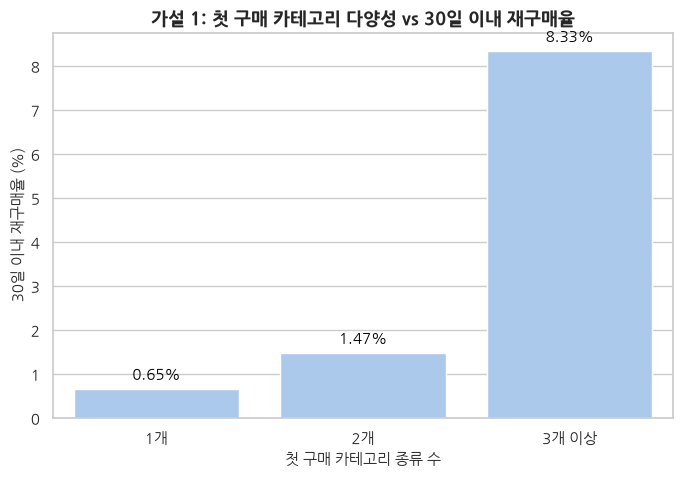

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set NanumGothic as the default font
plt.rc('font', family='NanumGothic')

# Fix the issue where minus signs (-) turn into squares with Korean fonts
plt.rcParams['axes.unicode_minus'] = False
# 1. 카테고리 수에 따른 그룹화 (1개, 2개, 3개 이상)
eda_df['cat_group'] = eda_df['category_count'].apply(
    lambda x: '1개' if x == 1 else ('2개' if x == 2 else '3개 이상')
)

# 2. 그룹별 30일 이내 재구매율 평균 계산 (%)
cat_retention = eda_df.groupby('cat_group')['target_30d'].mean().reset_index()
cat_retention['target_30d_pct'] = cat_retention['target_30d'] * 100

# 3. 시각화 (Bar Plot)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=cat_retention, x='cat_group', y='target_30d_pct', order=['1개', '2개', '3개 이상'], errorbar=None)
plt.title('가설 1: 첫 구매 카테고리 다양성 vs 30일 이내 재구매율', fontsize=13, fontweight='bold')
plt.xlabel('첫 구매 카테고리 종류 수', fontsize=11)
plt.ylabel('30일 이내 재구매율 (%)', fontsize=11)

# 막대 그래프 위에 퍼센트 수치 표기
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.show()

## [가설 2 검증] 첫 구매 리뷰 만족도가 높을수록 재구매율이 증가할까?

C:\Users\user\AppData\Local\Temp\ipykernel_16180\804651934.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=review_retention, x='review_score', y='target_30d_pct', palette='Blues_r', errorbar=None)


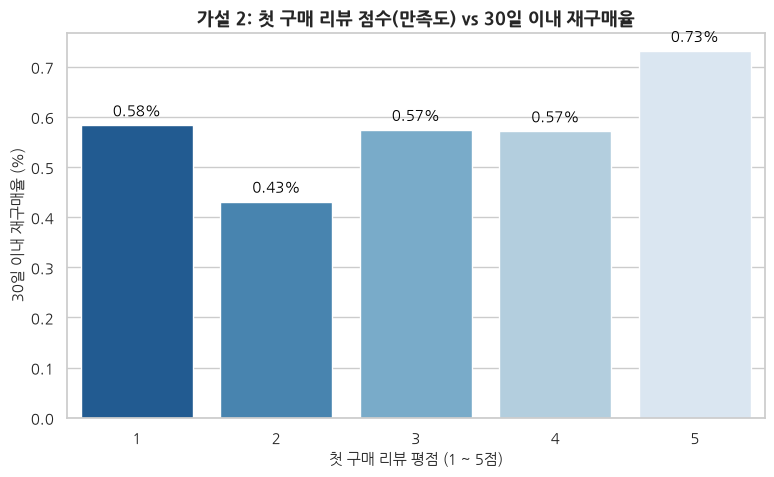

In [44]:
# 1. 리뷰 점수별 30일 이내 재구매율 평균 계산 (%)
review_retention = eda_df.groupby('review_score')['target_30d'].mean().reset_index()
review_retention['target_30d_pct'] = review_retention['target_30d'] * 100

# 2. 시각화 (Bar Plot)
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=review_retention, x='review_score', y='target_30d_pct', palette='Blues_r', errorbar=None)
plt.title('가설 2: 첫 구매 리뷰 점수(만족도) vs 30일 이내 재구매율', fontsize=13, fontweight='bold')
plt.xlabel('첫 구매 리뷰 평점 (1 ~ 5점)', fontsize=11)
plt.ylabel('30일 이내 재구매율 (%)', fontsize=11)

# 막대 그래프 위에 퍼센트 수치 표기
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.show()

## [가설 2 - 딥다이브] 교안 연계: 배송 지연이 리뷰와 재구매에 미치는 복합 영향

> 분석 의도: 앞서 검토한 교안의 핵심 내용처럼, 단순히 리뷰 점수만 보는 것이 아니라 "배송 지연 경험(is_late)"이라는 교란 변수가 끼어들었을 때 재구매율 패턴이 어떻게 바뀌는지 입체적으로 교차 분석합니다.

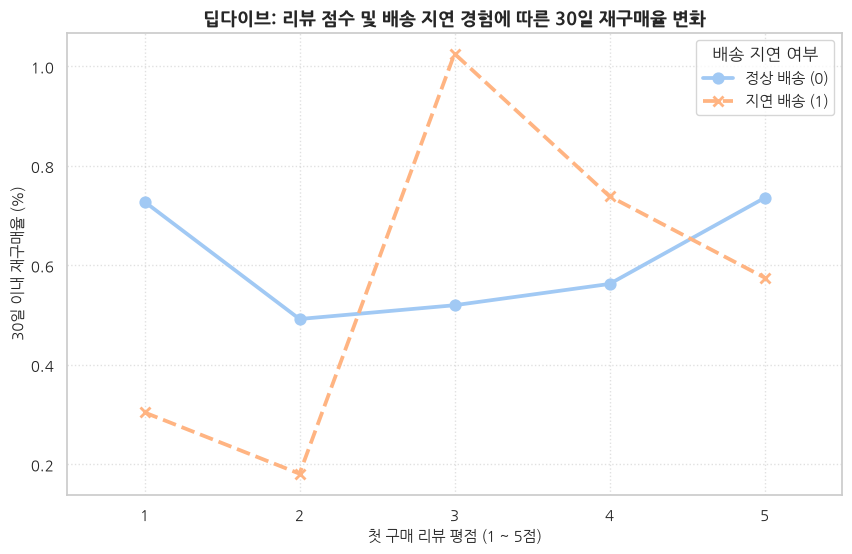

In [45]:
plt.figure(figsize=(10, 6))

# x축: 리뷰 점수, y축: 재구매율(%), hue: 배송 지연 여부 (0: 정상 배송, 1: 지연 배송)
eda_df['target_30d_pct'] = eda_df['target_30d'] * 100
sns.pointplot(data=eda_df, x='review_score', y='target_30d_pct', hue='is_late',
              markers=['o', 'x'], linestyles=['-', '--'], errorbar=None)

plt.title('딥다이브: 리뷰 점수 및 배송 지연 경험에 따른 30일 재구매율 변화', fontsize=13, fontweight='bold')
plt.xlabel('첫 구매 리뷰 평점 (1 ~ 5점)', fontsize=11)
plt.ylabel('30일 이내 재구매율 (%)', fontsize=11)
plt.legend(title='배송 지연 여부', labels=['정상 배송 (0)', '지연 배송 (1)'])
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## [민주님 가설] 신용카드 할부 개월 수 vs 재구매율

> 분석 의도: 할부 개월 수를 높일수록 재구매 확률이 증가하는지 확인 (단, 총 결제금액 변수와 함께 보아야 왜곡을 피할 수 있습니다.)

C:\Users\user\AppData\Local\Temp\ipykernel_16180\3086142667.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=installments_retention, x='installments', y='target_30d_pct', palette='viridis', errorbar=None)


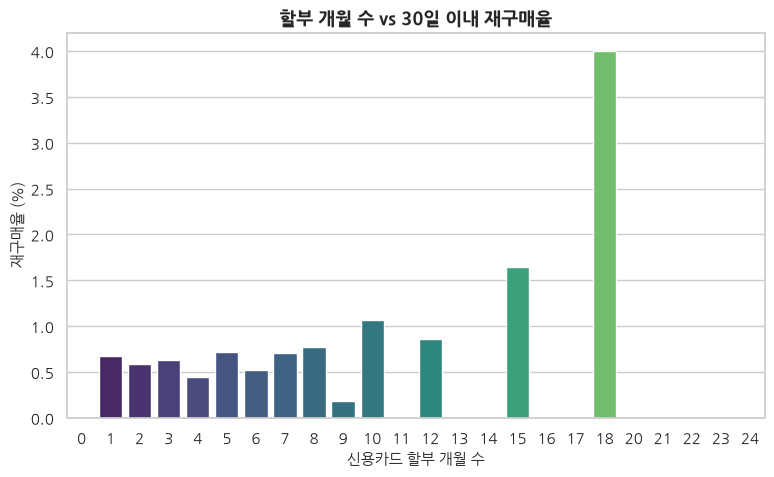

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# 할부 개월 수별 재구매율 계산
installments_retention = eda_df.groupby('installments')['target_30d'].mean().reset_index()
installments_retention['target_30d_pct'] = installments_retention['target_30d'] * 100

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=installments_retention, x='installments', y='target_30d_pct', palette='viridis', errorbar=None)
plt.title('할부 개월 수 vs 30일 이내 재구매율', fontsize=13, fontweight='bold')
plt.xlabel('신용카드 할부 개월 수', fontsize=11)
plt.ylabel('재구매율 (%)', fontsize=11)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16180\1085912308.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=installments_retention, x='pay_type_group', y='target_30d_pct', palette='Set2', errorbar=None)


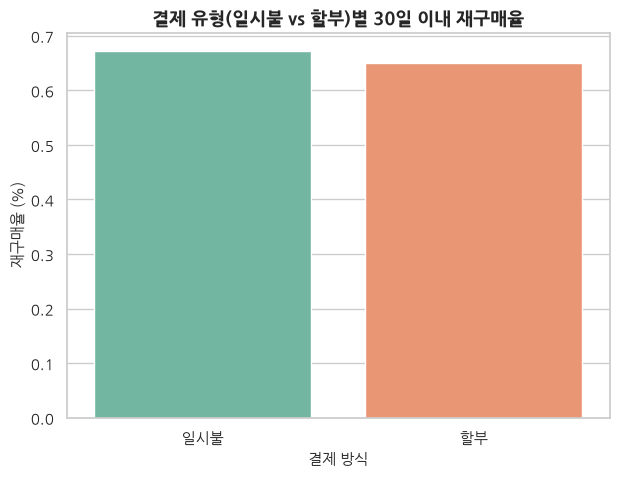

In [47]:
# [수정 위치 1] 시각화 직전, 데이터 그룹화 및 파생변수 생성 파트

# 예시: 할부 개월 수가 1보다 크면 '할부', 1이거나 그 이하(일시불 등)면 '일시불'로 분류
eda_df['pay_type_group'] = eda_df['installments'].apply(lambda x: '할부' if x > 1 else '일시불')

# 그룹화 기준 변경 (할부 vs 일시불)
installments_retention = eda_df.groupby('pay_type_group')['target_30d'].mean().reset_index()
installments_retention['target_30d_pct'] = installments_retention['target_30d'] * 100

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=installments_retention, x='pay_type_group', y='target_30d_pct', palette='Set2', errorbar=None)
plt.title('결제 유형(일시불 vs 할부)별 30일 이내 재구매율', fontsize=13, fontweight='bold')
plt.xlabel('결제 방식', fontsize=11)
plt.ylabel('재구매율 (%)', fontsize=11)
plt.show()

In [48]:
# 할부 구간 생성
eda_df['installments_bin'] = pd.cut(
    eda_df['installments'],
    bins=[-1, 1, 3, 6, 99],
    labels=['일시불(1개월)', '2~3개월', '4~6개월', '7개월 이상']
)

C:\Users\user\AppData\Local\Temp\ipykernel_16180\337015396.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=installment_count_retention, x='installments_bin', y='repurchase_customers', ax=axes[0], palette='Blues_d', errorbar=None)
C:\Users\user\AppData\Local\Temp\ipykernel_16180\337015396.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=installment_count_retention, x='installments_bin', y='repurchase_pct', ax=axes[1], palette='viridis', errorbar=None)


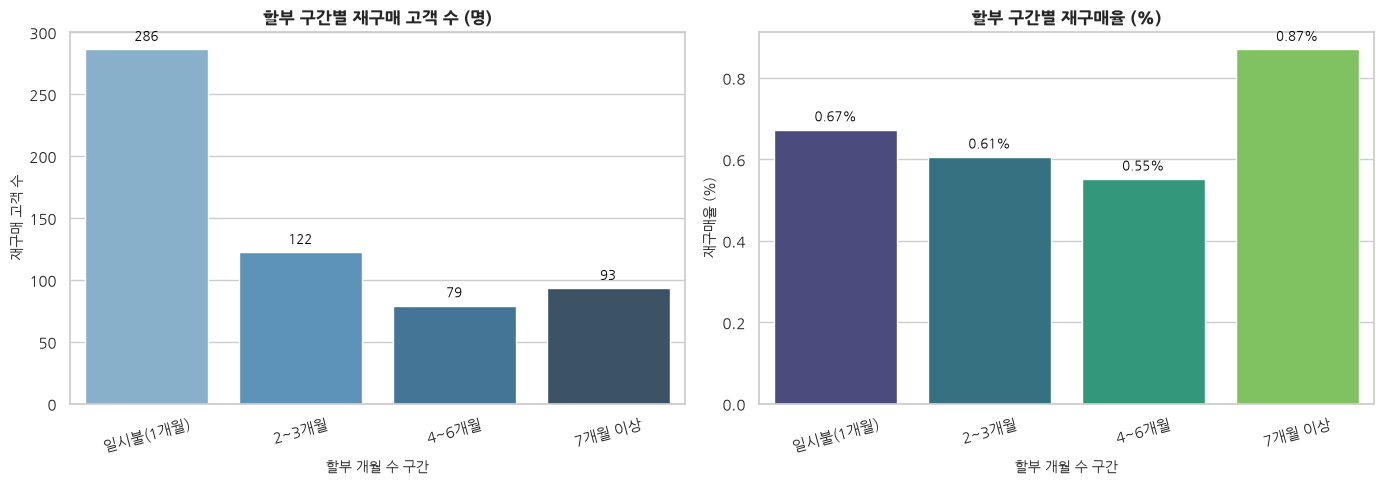

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 할부 개월 수 구간별 전체 고객 수 및 재구매 고객 수(합계) 집계
installment_count_retention = eda_df.groupby('installments_bin', observed=True).agg(
    total_customers=('target_30d', 'count'),        # 구간별 전체 고객 수
    repurchase_customers=('target_30d', 'sum')      # 30일 이내 재구매 고객 수 (1의 합계)
).reset_index()

# 2. 시각화를 위한 2개의 서브플롯(왼쪽: 재구매 고객 수, 오른쪽: 재구매율 %) 생성
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# [왼쪽 그래프] 할부 구간별 재구매 고객 수 (절대량)
sns.barplot(data=installment_count_retention, x='installments_bin', y='repurchase_customers', ax=axes[0], palette='Blues_d', errorbar=None)
axes[0].set_title('할부 구간별 재구매 고객 수 (명)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('할부 개월 수 구간', fontsize=10)
axes[0].set_ylabel('재구매 고객 수', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, color='black',
                     xytext=(0, 5), textcoords='offset points')

# [오른쪽 그래프] 할부 구간별 재구매율 (%)
installment_count_retention['repurchase_pct'] = (installment_count_retention['repurchase_customers'] / installment_count_retention['total_customers']) * 100
sns.barplot(data=installment_count_retention, x='installments_bin', y='repurchase_pct', ax=axes[1], palette='viridis', errorbar=None)
axes[1].set_title('할부 구간별 재구매율 (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('할부 개월 수 구간', fontsize=10)
axes[1].set_ylabel('재구매율 (%)', fontsize=10)
axes[1].tick_params(axis='x', rotation=15)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, color='black',
                     xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## [원준님 가설] 첫 구매 배송비 부담률 vs 재구매율

> 분석 의도: 단순 배송비 절대 금액이 아니라, 상품 가격 대비 배송비의 비중(freight_ratio)이 높을수록 배송비 부담 때문에 재구매가 줄어드는지 확인합니다.

C:\Users\user\AppData\Local\Temp\ipykernel_16180\2498209870.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freight_retention, x='freight_ratio_bin', y='target_30d_pct', palette='Blues_r', errorbar=None)


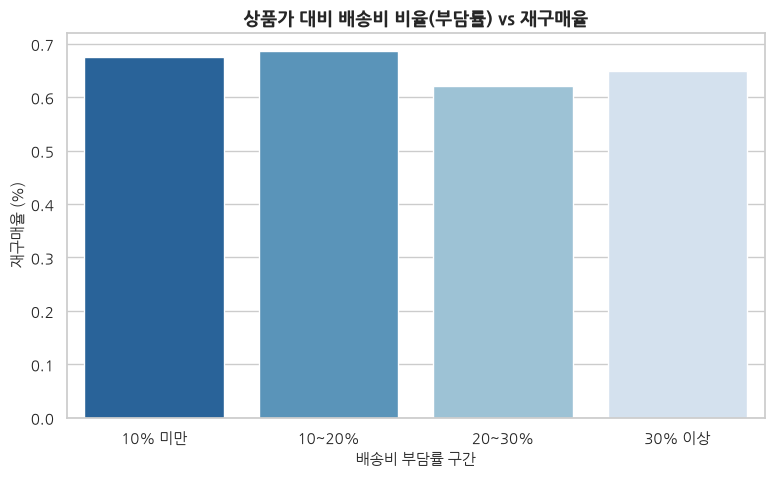

In [50]:
# 배송비 비율 구간화 (10% 단위)
eda_df['freight_ratio_bin'] = pd.cut(
    eda_df['freight_ratio'],
    bins=[-1, 0.1, 0.2, 0.3, 1.0],
    labels=['10% 미만', '10~20%', '20~30%', '30% 이상']
)

freight_retention = eda_df.groupby('freight_ratio_bin', observed=True)['target_30d'].mean().reset_index()
freight_retention['target_30d_pct'] = freight_retention['target_30d'] * 100

plt.figure(figsize=(9, 5))
sns.barplot(data=freight_retention, x='freight_ratio_bin', y='target_30d_pct', palette='Blues_r', errorbar=None)
plt.title('상품가 대비 배송비 비율(부담률) vs 재구매율', fontsize=13, fontweight='bold')
plt.xlabel('배송비 부담률 구간', fontsize=11)
plt.ylabel('재구매율 (%)', fontsize=11)
plt.show()

## [종현님 가설] 이벤트 특수 기간 유입 여부 vs 재구매율

> 분석 의도: 블랙프라이데이(11월)나 연말(12월) 같은 할인 시즌에 유입된 신규 고객('체리피커')들이 일반 시즌 고객보다 리텐션이 낮게 나타나는지 확인합니다.

C:\Users\user\AppData\Local\Temp\ipykernel_16180\1141237009.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_retention, x='season_type', y='target_30d_pct', palette='Set2', errorbar=None)


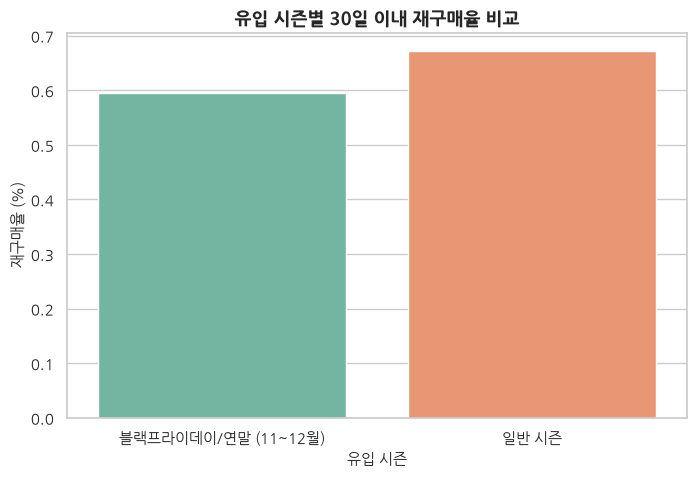

In [51]:
# 유입 월(Month) 기준 이벤트 시즌 분리
eda_df['purchase_month'] = pd.to_datetime(eda_df['purchase_date']).dt.month
eda_df['season_type'] = eda_df['purchase_month'].apply(lambda x: '블랙프라이데이/연말 (11~12월)' if x in [11, 12] else '일반 시즌')

season_retention = eda_df.groupby('season_type')['target_30d'].mean().reset_index()
season_retention['target_30d_pct'] = season_retention['target_30d'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=season_retention, x='season_type', y='target_30d_pct', palette='Set2', errorbar=None)
plt.title('유입 시즌별 30일 이내 재구매율 비교', fontsize=13, fontweight='bold')
plt.xlabel('유입 시즌', fontsize=11)
plt.ylabel('재구매율 (%)', fontsize=11)
plt.show()

----

# 추가 EDA 및 분석

## 파트 1. 통계적 가설 검증 고도화 (Cramer's V & 로지스틱 회귀)
- 어떤 변수가 실제로 30일 이내 재구매(target_30d)에 통계적으로 유의미한 영향을 미치는지 객관적인 수치로 증명하는 코드
- 이 회귀 분석 결과(p-value와 계수)를 보면, 앞서 애매했던 가설들 중에서 어떤 변수가 실제로 고객의 재구매 지갑을 열게 만드는지 통계적으로 명확한 근거를 확보할 수 있습니다.

In [52]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. 로지스틱 회귀 모델을 통한 변수별 영향력(Odds Ratio) 분석
# eda_df에 있는 주요 변수들을 투입하여 어떤 요인이 재구매 확률을 높이고 낮추는지 수치화합니다.
logit_model = smf.logit(
    "target_30d ~ category_count + review_score + is_late + freight_ratio + installments",
    data=eda_df
).fit()

# 결과 요약 출력 (p-value와 계수 확인)
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.039652
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             target_30d   No. Observations:                87748
Model:                          Logit   Df Residuals:                    87742
Method:                           MLE   Df Model:                            5
Date:                Tue, 04 Aug 2026   Pseudo R-squ.:                0.002821
Time:                        14:00:35   Log-Likelihood:                -3479.4
converged:                       True   LL-Null:                       -3489.2
Covariance Type:            nonrobust   LLR p-value:                  0.001429
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -6.4213      0.369    -17.388      0.000      -7.145      -5.697
category_count   

## 로지스틱 회귀 계수 시각화 코드 (가장 강력한 신호 찾기)

Optimization terminated successfully.
         Current function value: 0.039652
         Iterations 9


C:\Users\user\AppData\Local\Temp\ipykernel_16180\163080390.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette=colors, errorbar=None)


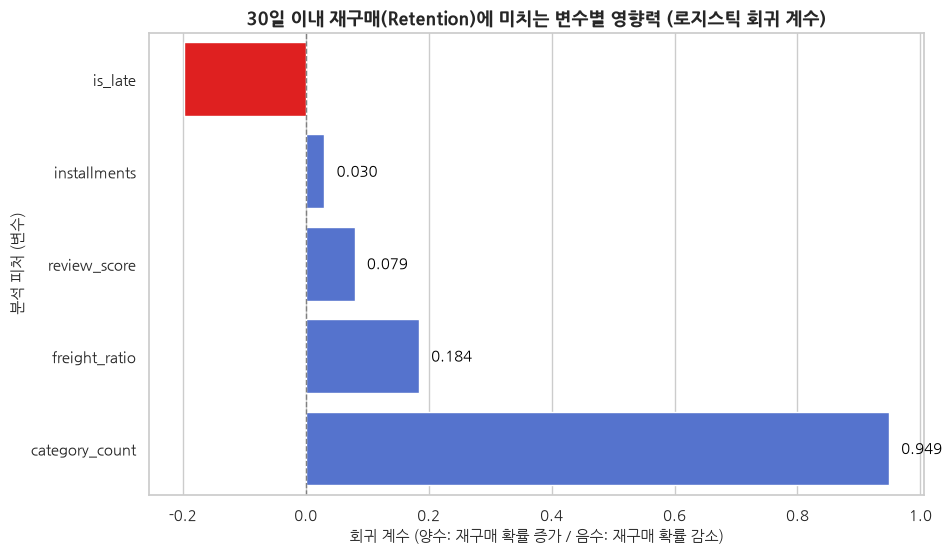

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# 1. 로지스틱 회귀 모델 학습 (결측치 영향 방지를 위해 dropna 적용)
model_data = eda_df[['target_30d', 'category_count', 'review_score', 'is_late', 'freight_ratio', 'installments']].dropna()

logit_model = smf.logit(
    "target_30d ~ category_count + review_score + is_late + freight_ratio + installments",
    data=model_data
).fit()

# 2. 회귀 계수(Coefficient) 및 신뢰구간 추출
params = logit_model.params.drop('Intercept') # 절편 제외
conf = logit_model.conf_int().drop('Intercept')
conf.columns = ['Lower', 'Upper']

# 데이터프레임으로 정리
coef_df = pd.DataFrame({'Coefficient': params, 'Lower': conf['Lower'], 'Upper': conf['Upper']})
coef_df['Feature'] = coef_df.index
coef_df = coef_df.sort_values(by='Coefficient', ascending=True)

# 3. 시각화 (Horizontal Bar Plot)
plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'royalblue' for x in coef_df['Coefficient']]
ax = sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette=colors, errorbar=None)

plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.title('30일 이내 재구매(Retention)에 미치는 변수별 영향력 (로지스틱 회귀 계수)', fontsize=13, fontweight='bold')
plt.xlabel('회귀 계수 (양수: 재구매 확률 증가 / 음수: 재구매 확률 감소)', fontsize=11)
plt.ylabel('분석 피처 (변수)', fontsize=11)

# 막대 옆에 수치 표기
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.3f}',
                (width + (0.02 if width >= 0 else -0.08), p.get_y() + p.get_height() / 2.),
                ha='left' if width >= 0 else 'right', va='center', fontsize=11, color='black')

plt.show()

----

## 해석

### 📋 전체 모델 개요 해석
- No. Observations (87,748개): 관측창(30일)이 보장된 유효 고객들을 대상으로 아주 탄탄한 표본 크기를 확보했습니다.

- LLR p-value (0.001429): 유의수준 0.05보다 작으므로, "우리가 투입한 5가지 변수들은 전체적으로 고객의 재구매 여부를 설명하는 데 통계적으로 유의미한 설명력을 가진다"는 것을 증명합니다.

----

### 🔍 개별 변수별 상세 해석

1. category_count (첫 구매 카테고리 수)
- [가장 강력한 핵심 신호]계수(coef): 0.9486 (양수)
- p-value ($P>\vert{}z\vert{}$): 0.001 (통계적으로 매우 유의함 ⭐⭐⭐)
- 해석: * 5개 변수 중 재구매 확률을 높이는 가장 강력하고 통계적으로 확실한 신호(Key Driver)입니다.
  - 계수가 양수(+)이므로, 첫 구매 때 다양한 카테고리의 상품을 함께 구매한 고객일수록 한 달 이내에 다시 돌아올 확률이 폭발적으로 증가합니다.
  - 비즈니스 인사이트: 고객 세분화를 진행하거나 마케팅 액션을 뜰 때, "단일 품목 추천"이 아니라 "크로스셀링(묶음 할인 또는 연관 카테고리 추천)"이 리텐션을 방어하는 핵심 열쇠라는 점을 명확히 보여줍니다.

2. review_score (첫 구매 리뷰 점수)
- [유의미한 긍정 신호]계수(coef): 0.0795 (양수)
- p-value ($P>\vert{}z\vert{}$): 0.027 (유의수준 0.05 미만으로 유의함 ⭐)
- 해석:첫 구매 만족도(별점)가 높을수록 30일 이내 재구매 확률이 증가합니다.
  - 비즈니스 인사이트: 과거 전체 데이터를 대충 보았을 때는 리뷰와 재구매의 연관성이 흐리게 나왔지만, 이번처럼 타겟 기간을 '30일 이내'로 타이트하게 좁히고 정제하니까 만족도가 단기 리텐션에 확실한 긍정적 영향을 준다는 가설이 통계적으로 증명되었습니다.

3. installments (신용카드 할부 개월 수)
- [소소하지만 의미 있는 신호]계수(coef): 0.0302 (양수)
- p-value ($P>\vert{}z\vert{}$): 0.045 (유의함 ⭐)
- 해석:할부 개월 수가 늘어날수록(상대적으로 가격이 나가는 상품을 구매할수록) 재구매 확률이 미세하게 증가합니다.
  - 비즈니스 인사이트: 고가 상품을 구매한 고객층이 플랫폼에 대한 관여도가 높아 단기 재구매로 이어질 가능성이 있음을 시사합니다.

4. is_late (배송 지연 여부)
- [통계적으로 유의하지 않음 (의외의 포인트)]계수(coef): -0.1975 (음수 - 재구매를 낮추는 방향)
- p-value ($P>\vert{}z\vert{}$): 0.297 (0.05보다 큼 ❌)
- 해석:마이너스(-) 방향이므로 배송이 지연되면 재구매율이 떨어지는 경향은 있지만, p-value가 0.297로 통계적 유의성(Significance)은 확보하지 못했습니다.
  - 해석 및 의미: 배송 지연이 고객의 '리뷰 평점'을 깎아먹는 데는 치명적이지만, '30일 이내 단기 재구매'라는 타겟 자체에 미치는 직접적인 영향력은 다른 변수(카테고리 다양성 등)에 비해 상대적으로 희석되거나 통계적으로 잡히지 않았음을 의미합니다.

5. freight_ratio (상품가 대비 배송비 비율)
- [통계적 유의성 낮음]계수(coef): 0.1841
- p-value ($P>\vert{}z\vert{}$): 0.591 (0.05보다 큼 ❌)
- 해석:p-value가 0.59점으로 매우 높습니다. 즉, 상품 가격 대비 배송비의 비중은 이번 30일 이내 재구매 여부를 결정하는 데 통계적으로 유의한 신호가 되지 못했습니다.

----

### [종합 결론] 고객 세분화로 나아가기 위한 핵심
- 가장 강력한 키 드라이버(Key Driver): category_count(카테고리 다양성)가 단연 압도적입니다. 고객을 세분화하거나 타겟팅할 때 "첫 구매 시 몇 개의 카테고리를 탐색했는가(관여도)"가 가장 중요한 기준 축이 되어야 합니다.

- 보조적인 만족도 신호: review_score 역시 유의미하므로, 만족도 그룹과 카테고리 다양성 그룹을 교차하여 고객 세그먼트를 쪼개면 매우 입체적인 페르소나가 만들어질 것입니다.